# Import libraries

In [ ]:
import torch
import torch.nn as nn # Neutal network module
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation
import numpy as np

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

# Check GPU

In [12]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


# Download Datasets

In [26]:
# converts images into PyTorch tensors. For MNIST, Original image: 28 × 28 pixels becomes 1 × 28 × 28 Tensor
# The pixel values are also scaled from: 0–255 to 0.0–1.0
transform = transforms.ToTensor()
# Load the MNIST Dataset
train_dataset = datasets.MNIST(root = "../datasets/", train = True, download = True, transform=transform)
test_dataset = datasets.MNIST(root="../datasets/", train = False, download = True, transform=transform)

In [27]:
print("Number of training samples: " + str(len(train_dataset)) + "\n" +
      "Number of testing samples: " + str(len(test_dataset)))
print("Datatype of the 1st training sample: ", train_dataset[0][0].type())
print("Size of the 1st training sample: ", train_dataset[0][0].size())

Number of training samples: 60000
Number of testing samples: 10000
Datatype of the 1st training sample:  torch.FloatTensor
Size of the 1st training sample:  torch.Size([1, 28, 28])


# Create dataloaders

In [102]:
# data is loaded into a DataLoader with batch size at 64
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Explore Dataset

In [103]:
image, label = next(iter(train_loader))

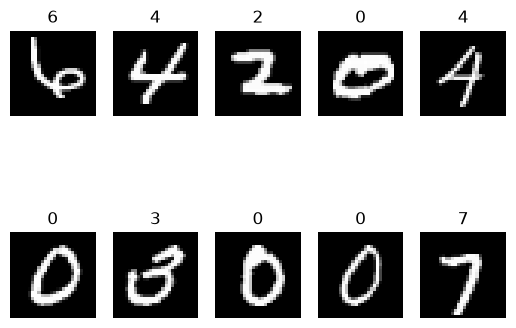

In [105]:
fig, axes = plt.subplots(2,5)
for i, ax in enumerate(axes.flat):
    ax.imshow(image[i].squeeze(), cmap = "gray")
    ax.set_title(label[i].item())
    ax.axis("off")

# Logistic Regression

Logistic regression is a supervised machine learning algorithm used for classification, predicting the probability of an event (e.g., yes/no) rather than continuous numbers. It models data using an S-shaped sigmoid function, mapping inputs to probabilities between 0 and 1.

In [106]:
# This model will take a 28 ×28-pixel image of handwritten digits as input 
# and classify them into one of the 10 output classes of digits 0 to 9.
class LogisticRegression (nn.Module):
    def __init__(self, n_inputs, n_outputs):
        # super().__init__(): Triggers the constructor of the parent class (nn.Module).
        # It sets up internal PyTorch registries necessary for tracking weights, biases, and submodules.
        super().__init__()
        #self.linear = nn.Linear(...): Registers a fully connected (dense) layer as an attribute of the class.
        # 28*28: Sets the input feature size to 784, matching the total pixels of a flattened 28 × 28 
        # 10: Sets the output size to 10, creating one raw score (logit) for each potential target class.
        self.linear = nn.Linear(28*28, 10) 

    def forward(self,x):
        # The sigmoid function is an activation function that converts any real number into a value between 0 and 1.
        # self.linear(x) computes the raw score (logit).
        # torch.sigmoid(...) converts that score into a value between 0 and 1.
        # y_pred becomes a probability-like output that is well suited for binary classification.
        y_predict = torch.sigmoid(self.linear(x))
        return y_predict

In [108]:
# instantiate the model
n_inputs = 28*28 # makes a 1D vector of 784
n_outputs = 10
log_regr = LogisticRegression(n_inputs, n_outputs)

In [109]:
# defining the optimizer
# Uses Stochastic Gradient Descent (SGD).
# The learning rate (lr=0.001) controls how much the weights are updated during each optimization step.
optimizer = torch.optim.SGD(log_regr.parameters(), lr=0.001)
# defining Cross-Entropy loss
# This computes the difference between the predicted logits and the true class labels for multiclass classification.
criterion = torch.nn.CrossEntropyLoss()

In [110]:
epochs = 50
loss_total = []
accuracy_total = []
# Training loop
# Each batch contains 64 images and 64 labels
for epoch in range(epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Prevents gradients from accumulating across batches.
        optimizer.zero_grad()
        # image.view(-1, 28*28) means flatten images. Changes the shape from 64×1×28×28 to 64×784 because a linear layer expects vectors as input.
    
        # Forward Pass 
        # Produces a prediction for each image in the batch.
        outputs = log_regr(images.view(-1, 28*28))

        # Compute Loss
        # Measures how far the predictions are from the true labels.
        loss = criterion(outputs, labels)

        # Backpropagation
        # Computes the gradients of the loss with respect to all trainable parameters.
        loss.backward()

        # Update Parameters
        # Uses the computed gradients to update the weights and biases.
        optimizer.step()
        
    loss_total.append(loss.item())
    correct = 0
    for images, labels in test_loader:
        outputs = log_regr(images.view(-1, 28*28))
        # Predict the Class
        # Suppose the model outputs [0.2, 1.5, -0.3, ..., 2.7] The largest value is at index 9, so the predicted digit is 9.
        _, predicted = torch.max(outputs.data,1)
        #print(predicted)
        # Count Correct Predictions
        # Adds the number of correct predictions in the current batch.
        correct += (predicted == labels).sum()
    # If the model correctly classifies 9,200 out of 10,000 test images, Accuracy = 92%
    accuracy = 100 * (correct.item())/len(test_dataset)
    accuracy_total.append(accuracy)
    print('Epoch: {}. Loss: {}. Accuracy: {}'.format(epoch, loss.item(), accuracy))


Epoch: 0. Loss: 2.2335286140441895. Accuracy: 41.52
Epoch: 1. Loss: 2.1966538429260254. Accuracy: 63.71
Epoch: 2. Loss: 2.1631217002868652. Accuracy: 71.18
Epoch: 3. Loss: 2.112595558166504. Accuracy: 74.49
Epoch: 4. Loss: 2.074568271636963. Accuracy: 76.49
Epoch: 5. Loss: 2.0371429920196533. Accuracy: 77.63
Epoch: 6. Loss: 1.9854768514633179. Accuracy: 78.7
Epoch: 7. Loss: 1.984738826751709. Accuracy: 79.43
Epoch: 8. Loss: 1.9850287437438965. Accuracy: 79.96
Epoch: 9. Loss: 1.9617851972579956. Accuracy: 80.52
Epoch: 10. Loss: 1.934202790260315. Accuracy: 80.94
Epoch: 11. Loss: 1.9148849248886108. Accuracy: 81.29
Epoch: 12. Loss: 1.9043606519699097. Accuracy: 81.67
Epoch: 13. Loss: 1.906471848487854. Accuracy: 81.88
Epoch: 14. Loss: 1.8579941987991333. Accuracy: 81.99
Epoch: 15. Loss: 1.8660588264465332. Accuracy: 82.24
Epoch: 16. Loss: 1.8436310291290283. Accuracy: 82.41
Epoch: 17. Loss: 1.8967286348342896. Accuracy: 82.52
Epoch: 18. Loss: 1.873265266418457. Accuracy: 82.59
Epoch: 19.

# Loss plot

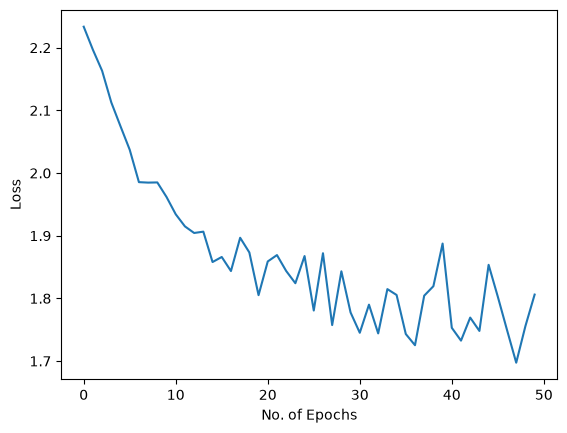

In [111]:
plt.plot(loss_total)
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.show()

# Accuracy plot

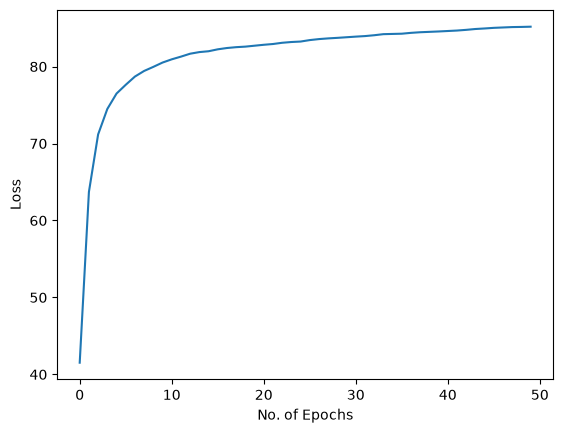

In [112]:
plt.plot(accuracy_total)
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.show()